Algorithme SVM

In [1]:
import numpy as np                           
import pandas as pd                          
import matplotlib.pyplot as plt              

print("SVM - SUPPORT VECTOR MACHINE (from scratch)")
df = pd.read_csv('auto_mpg.csv')
# creer la variable cible binaire : SVM utilise les classes -1 et +1 (pas 0 et 1)
df['economique'] = (df['mpg'] > df['mpg'].median()).astype(int)

features = ['weight', 'horsepower']          # variables explicatives (2D pour visualisation)
X = df[features].values                      # variable explicative sous forme de matrice
y_01  = df['economique'].values              # variable cible originale (0 et 1)
y_svm = np.where(y_01 == 0, -1, 1)          # SVM utilise les classes -1 et +1 (pas 0 et 1)





def normaliser(X):                                        # normalisation min-max pour stabiliser la descente de gradient
    X_min = X.min(axis=0)#  valeur min de chaque colonne 
    X_max = X.max(axis=0)#  valeur max de chaque colonne
    return (X - X_min) / (X_max - X_min + 1e-8)          # eviter la division par zero




X_n = normaliser(X)                          # normaliser toutes les données





def svm_scratch(X, y, lr=0.001, C=1.0, n_iter=1000):     # SVM linéaire par descente de gradient (Hinge Loss)
    n, p = X.shape                                        # n : nbr d'exemples , p : nbr de features
    w = np.zeros(p)                                       # initialiser les poids à 0
    b = 0                                                 # initialiser le biais à 0
    losses = []                                           # stocker la perte à chaque itération

    for _ in range(n_iter):
        loss = 0
        for i in range(n):
            # condition de marge : yi · (w·xi + b) >= 1
            cond = y[i] * (np.dot(w, X[i]) + b)          # yi · (w·xi + b)

            if cond >= 1:                                 # point bien classé ET dans la marge
                # gradient = régularisation seulement   ∂L/∂w = w
                w -= lr * w                              
            else:                                         # point mal classé OU dans la marge
                # gradient = régularisation - correction  ∂L/∂w = w - C·yi·xi
                w -= lr * (w - C * y[i] * X[i])          
                b += lr * C * y[i]                        # mise à jour du biais
                loss += 1 - cond                          # hinge loss : max(0, 1 - yi·(w·xi + b))

        # Hinge Loss total = (1/2)||w||² + C · Σ max(0, 1 - yi·(w·xi+b))
        losses.append(0.5 * np.dot(w, w) + C * loss / n) 

    return w, b, losses





w_svm, b_svm, losses_svm = svm_scratch(X_n, y_svm)  # entrainer le modèle SVM sur toutes les données

# prédire les classes : signe de (w·x + b)
scores   = X_n @ w_svm + b_svm                        # score de décision = w·x + b
pred_svm = np.sign(scores)                             # classe = signe du score (+1 ou -1)





#métriques d'évaluation                                       calcule
pred_01      = np.where(pred_svm == -1, 0, 1)             # reconvertir -1/+1 en 0/1 pour les métriques
accuracy_svm = np.mean(pred_01 == y_01)                   # ACCURACY
TP = np.sum((pred_01 == 1) & (y_01 == 1))                 # vrais positifs
TN = np.sum((pred_01 == 0) & (y_01 == 0))                 # vrais négatifs
FP = np.sum((pred_01 == 1) & (y_01 == 0))                 # faux positifs
FN = np.sum((pred_01 == 0) & (y_01 == 1))                 # faux négatifs
precision_svm = TP / (TP + FP + 1e-8)                     # PRECISION = TP / (TP + FP)
recall_svm    = TP / (TP + FN + 1e-8)                     # RECALL    = TP / (TP + FN)
f1_svm        = 2 * precision_svm * recall_svm / (precision_svm + recall_svm + 1e-8) # F1-SCORE





print(f"Vecteur w : weight={w_svm[0]:.4f}  horsepower={w_svm[1]:.4f}")
print(f"Biais   b = {b_svm:.4f}")
print(f"Accuracy  = {accuracy_svm:.4f}")
print(f"Precision = {precision_svm:.4f}")
print(f"Recall    = {recall_svm:.4f}")
print(f"F1-Score  = {f1_svm:.4f}")

print("_" * 80)

print("Matrice de Confusion (from scratch):")
print(f"  TP={TP}  FP={FP}")
print(f"  FN={FN}  TN={TN}")



SVM - SUPPORT VECTOR MACHINE (from scratch)
Vecteur w : weight=-0.1292  horsepower=-0.0589
Biais   b = -0.8490
Accuracy  = 0.5077
Precision = 0.0000
Recall    = 0.0000
F1-Score  = 0.0000
________________________________________________________________________________
Matrice de Confusion (from scratch):
  TP=0  FP=0
  FN=193  TN=199


In [ ]:
GRAPHES

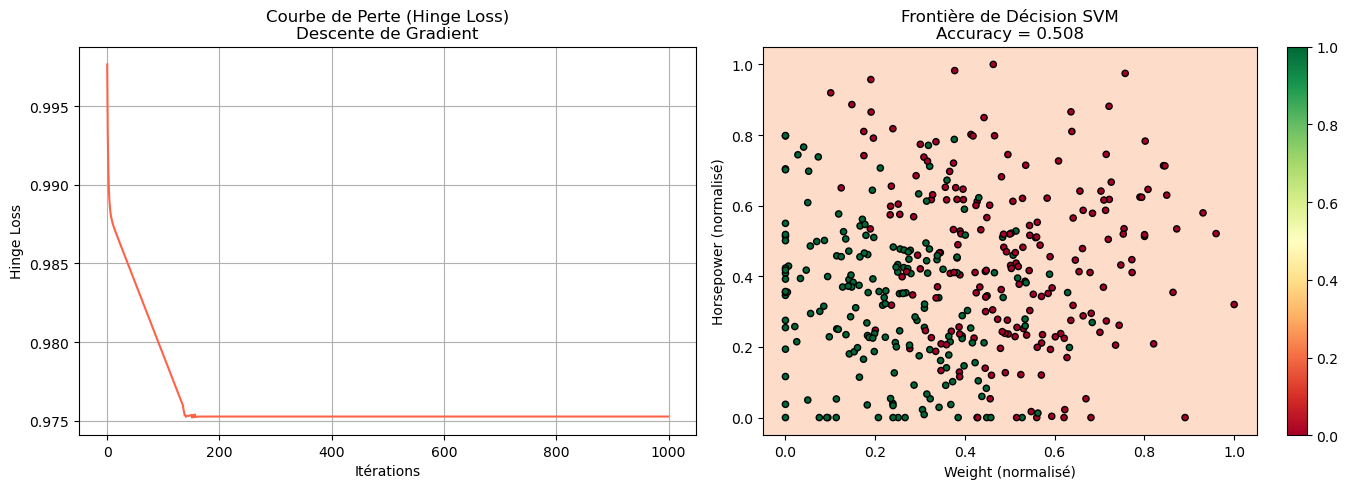

In [2]:


fig, axes = plt.subplots(1, 2, figsize=(14, 5))      

# courbe de la perte (convergence)
axes[0].plot(losses_svm, color='tomato')
axes[0].set_title('Courbe de Perte (Hinge Loss)\nDescente de Gradient')
axes[0].set_xlabel('Itérations')
axes[0].set_ylabel('Hinge Loss')
axes[0].grid(True)




# frontière de décision
x_min, x_max = X_n[:, 0].min() - 0.05, X_n[:, 0].max() + 0.05 
y_min, y_max = X_n[:, 1].min() - 0.05, X_n[:, 1].max() + 0.05 
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
grid   = np.c_[xx.ravel(), yy.ravel()]
Z_svm  = np.sign(grid @ w_svm + b_svm).reshape(xx.shape)  # frontière = là où w·x + b = 0

axes[1].contourf(xx, yy, Z_svm, alpha=0.3, cmap='RdYlGn')
scatter = axes[1].scatter(X_n[:, 0], X_n[:, 1], c=y_01, cmap='RdYlGn', edgecolors='k', s=20)
axes[1].set_title(f'Frontière de Décision SVM\nAccuracy = {accuracy_svm:.3f}')
axes[1].set_xlabel('Weight (normalisé)')
axes[1].set_ylabel('Horsepower (normalisé)')
plt.colorbar(scatter, ax=axes[1])





plt.tight_layout()                                    
plt.savefig('resultats_svm_scratch.png', dpi=150)         
plt.show()                                            